# 16. Earth, Moon, and Sun

The earlier system notebooks used the star as every world's tidal host. In the Earth-Moon-Sun system the roles separate: the Earth raises the Moon's tides, the Moon raises the Earth's tides, and the Sun only provides sunlight. Each world therefore carries two orbits, one about its tidal host for the tides and one about the star for insolation.

This notebook builds that system from the bundled worlds, makes the Earth and Moon a mutual pair, and compares single-body and dual-body dissipation against the measured lunar recession and the lengthening of the day. It then sweeps the obliquity of each body and the Moon's orbital period to show where the orbit expands and where it contracts.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import au, year
from TidalPy.structures_x.configs import build_world
from TidalPy.structures_x.system import System

CM_PER_YEAR = 100.0 * year   # converts [m s-1] to [cm yr-1]
CENTURY = 100.0 * year       # [s]

# Bundled worlds: a star, a three-layer Earth, and a five-layer Moon fitted to its k2 and Q
sun = build_world("sol")
earth = build_world("earth_simple")
moon = build_world("luna")

# Both layered worlds use the rheology tide model, which needs a solved interior
earth.solve_eos()
moon.solve_eos()

for world in (earth, moon):
    moi_factor = world.get_moment_of_inertia() / (world.mass * world.radius**2)
    print(f"{world.name:12} R = {world.radius / 1e3:7.1f} km   M = {world.mass:.4e} kg   C/MR^2 = {moi_factor:.4f}")

Earth-Simple R =  6371.0 km   M = 5.9720e+24 kg   C/MR^2 = 0.3307
Luna         R =  1737.4 km   M = 7.3458e+22 kg   C/MR^2 = 0.3931


## Building the System

The Sun is added as the star and given no tidal host, so nothing raises a tide on it. The Earth is added next with no host, since its host (the Moon) is not in the system yet. The Moon is added with the Earth as its tidal host and carries the orbit about the Earth. `set_tidal_host(earth, moon)` then makes the Moon the Earth's host, which turns the two into a mutual pair.

Two worlds that host each other share one orbit, so its elements are given on only one of them. The Earth carries no semi-major axis of its own and reads the Moon's.

In [2]:
system = System("Earth-Moon-Sun")
system.add_world(
    sun,
    is_star=True)                 # The insolation source and nobody's tidal host
system.add_world(earth)           # The Moon's tidal host; its own host is named below
system.add_world(
    moon,
    tidal_host=earth,             # The Earth raises the Moon's tides
    semi_major_axis=3.84748e8,    # Moon about the Earth [m]; 3.844e8 m is its mean distance, not the semi-major axis
    eccentricity=0.0549)
system.set_tidal_host(earth, moon)   # The Moon raises the Earth's tides in turn

for world in system:
    host = system.get_tidal_host(world)
    print(f"{world.name:12} tidal host: {host.name if host is not None else 'none':12} "
          f"mutual pair: {system.is_mutual_pair(world)}")
print(f"star: {system.star.name}")
print(f"Earth's orbit, read from the Moon: a = {system.get_semi_major_axis(earth):.4e} m, "
      f"e = {system.get_eccentricity(earth)}")

# The bundled Moon spins at the observed 27.322 day sidereal rate, which the two-body period at this semi-major axis
# matches only to the precision of the orbital elements. Any residual difference would add a slow tidal mode, so set
# the Moon to exact synchronous rotation.
orbital_frequency = system.calc_orbital_frequency(moon)   # [rad s-1]
moon.set_spin_frequency(orbital_frequency)
print(f"two-body orbital period: {2.0 * np.pi / orbital_frequency / 86400.0:.3f} days")

Sol          tidal host: none         mutual pair: False
Earth-Simple tidal host: Luna         mutual pair: True
Luna         tidal host: Earth-Simple mutual pair: True
star: Sol
Earth's orbit, read from the Moon: a = 3.8475e+08 m, e = 0.0549
two-body orbital period: 27.322 days


## Stellar Orbit and Insolation

The orbit about the star is separate from the orbit about the tidal host. It is set with `set_stellar_semi_major_axis` and `set_stellar_eccentricity` and used only for insolation. Here both the Earth and the Moon orbit the Sun at 1 au with Earth's eccentricity. `calc_insolation_flux` returns the orbit-averaged flux \[W m$^{-2}$\] and `calc_equilibrium_temperature` the gray-body temperature \[K\] from each world's own albedo and emissivity.

In [3]:
for world in (earth, moon):
    system.set_stellar_semi_major_axis(world, au)       # Orbit about the Sun [m]
    system.set_stellar_eccentricity(world, 0.0167)

print(f"{'world':12} {'albedo':>7} {'flux (W/m^2)':>13} {'T_eq (K)':>9}")
for world in (earth, moon):
    flux = system.calc_insolation_flux(world)
    temperature = system.calc_equilibrium_temperature(world)
    print(f"{world.name:12} {world.albedo:7.2f} {flux:13.1f} {temperature:9.1f}")

world         albedo  flux (W/m^2)  T_eq (K)
Earth-Simple    0.30        1361.4     254.6
Luna            0.12        1361.4     269.6


## Single-Body Evolution

`calc_world_evolution` solves the tides raised in one world and treats its host as a point mass. For the Earth that is the tide the Moon raises in the solid Earth. For the Moon it is the tide the Earth raises in the Moon. Each call returns that body's share of the orbital rates, its own spin rate, and its tidal heating \[W\].

The Earth rotates faster than the Moon orbits, so its tidal bulge leads the Moon. That bulge pulls the Moon forward, which raises the orbit (positive $da/dt$) and slows the Earth's spin. The synchronous Moon dissipates only through its eccentricity, which draws energy from the orbit and lowers it.

In [4]:
def length_of_day_rate(spin_frequency, dspin_dt):
    """Change in the length of day [ms per century] from a spin rate [rad s-1] and its derivative [rad s-2]."""
    return -2.0 * np.pi * dspin_dt / spin_frequency**2 * CENTURY * 1.0e3

print(f"{'dissipating body':16} {'heating (W)':>12} {'da/dt (cm/yr)':>14} {'de/dt (1/yr)':>13} {'dspin/dt (rad/s^2)':>19}")
single = {}
for world in (earth, moon):
    single[world.name] = evolution = system.calc_world_evolution(world)
    print(f"{world.name:16} {evolution['tidal_heating']:12.3e} {evolution['da_dt'] * CM_PER_YEAR:14.4f} "
          f"{evolution['de_dt'] * year:13.3e} {evolution['dspin_dt']:19.3e}")

earth_single = single[earth.name]
print(f"\nEarth's length of day from the tide in the solid Earth: "
      f"{length_of_day_rate(earth.spin_frequency, earth_single['dspin_dt']):+.3f} ms per century")

dissipating body  heating (W)  da/dt (cm/yr)  de/dt (1/yr)  dspin/dt (rad/s^2)
Earth-Simple        1.530e+11         0.1870     4.119e-13          -2.717e-23
Luna                6.306e+08        -0.0542    -4.737e-12           4.608e-21

Earth's length of day from the tide in the solid Earth: +0.101 ms per century


## Dual-Body Evolution

`calc_pair_evolution` solves both bodies' tides on the shared orbit, each with the other as the tide raiser, and adds their contributions to the orbital rates. The `world` and `host` entries hold each body's full single-body result, so the combined rate is the sum of the two rows above. The heating in both bodies balances the loss of orbital and spin energy, which `energy_residual` checks.

In [5]:
pair = system.calc_pair_evolution(moon)

recession = pair["da_dt"] * CM_PER_YEAR
print(f"combined da/dt : {recession:+.4f} cm/yr  (Earth {pair['host']['da_dt'] * CM_PER_YEAR:+.4f}, "
      f"Moon {pair['world']['da_dt'] * CM_PER_YEAR:+.4f})")
print(f"combined de/dt : {pair['de_dt'] * year:+.3e} 1/yr  (Earth {pair['host']['de_dt'] * year:+.3e}, "
      f"Moon {pair['world']['de_dt'] * year:+.3e})")
print(f"Earth heating  : {pair['host']['tidal_heating']:.3e} W")
print(f"Moon heating   : {pair['world']['tidal_heating']:.3e} W")
print(f"total heating  : {pair['tidal_heating_total']:.3e} W")
print(f"relative energy residual: {pair['energy_residual'] / pair['tidal_heating_total']:.1e}")

print(f"\nlunar laser ranging: 3.83 cm/yr, model: {recession:.3f} cm/yr "
      f"(ratio {3.83 / recession:.0f})")

combined da/dt : +0.1328 cm/yr  (Earth +0.1870, Moon -0.0542)
combined de/dt : -4.325e-12 1/yr  (Earth +4.119e-13, Moon -4.737e-12)
Earth heating  : 1.530e+11 W
Moon heating   : 6.306e+08 W
total heating  : 1.536e+11 W
relative energy residual: -2.0e-16

lunar laser ranging: 3.83 cm/yr, model: 0.133 cm/yr (ratio 29)


The model's recession is far smaller than the 3.83 cm yr$^{-1}$ measured by lunar laser ranging (Williams and Boggs 2016), and its length-of-day change is a small fraction of the roughly 2.4 ms per century that tides are estimated to add. This shortfall is expected. The Earth model contains only solid layers and a liquid core, while most of Earth's present tidal dissipation, about 3.7 TW in total, takes place in its oceans. The solid-Earth heating here, about 0.15 TW, is close to estimates of the solid-body share. Three further simplifications apply:

- The Earth's only tidal host is the Moon. The solar tide on the Earth, which adds roughly a fifth to the spin-down torque, is not included.
- Only degree 2 is used, with the default eccentricity truncation.
- Both obliquities are zero so far. The next section changes that.

## Obliquity Tides

A world whose spin axis is tilted relative to its orbit normal feels an additional tide as the host moves above and below its equator. The obliquity terms are only included when the world's obliquity truncation is on: `obliquity_truncation="gen"` uses the general form, which is valid at any angle, while 0 (`"off"`) ignores obliquity entirely. Levels 2 and 4 keep the heating through $I^2$ and $I^4$ and are faster at small tilts (see notebook 17). `set_obliquity` \[rad\] then sets the tilt that the system reads on each call.

The sweep below tilts one body at a time from 0 to 90 degrees with the other held at zero. The Moon's obliquity to its orbit is about 6.7 degrees, and the Earth's equator is tilted between about 18 and 29 degrees from the Moon's orbit plane.

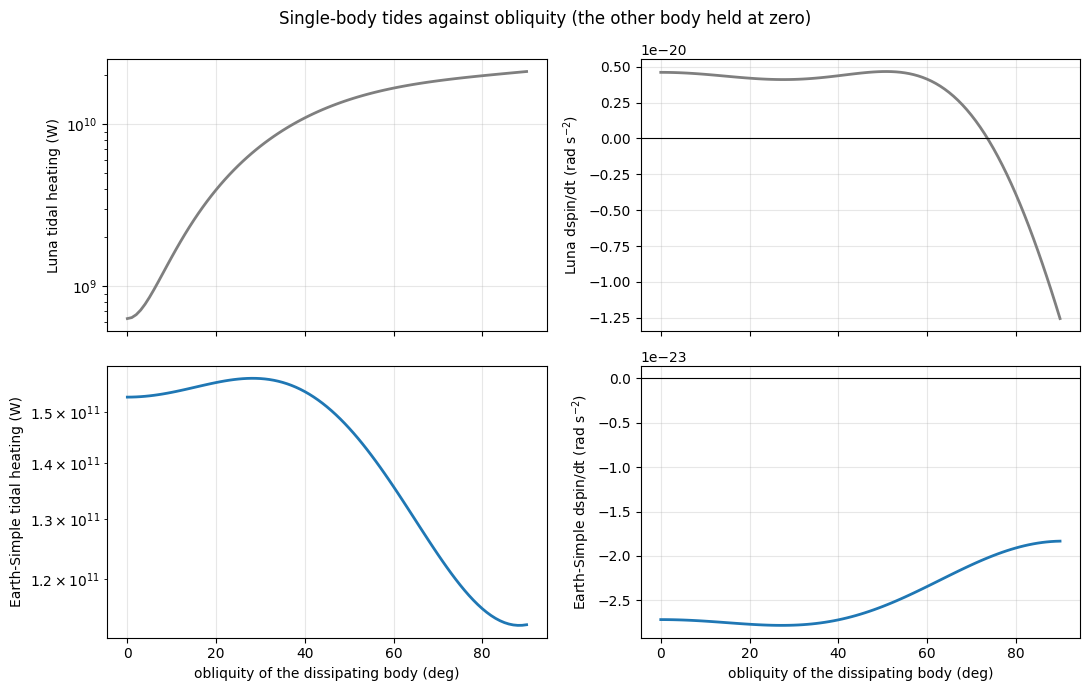

Moon heating at 6.68 deg : 1.029e+09 W (1.63 times the zero-obliquity value)
Earth heating at 23.4 deg: 1.565e+11 W
combined da/dt           : +0.1213 cm/yr
Earth's length of day    : +0.104 ms per century


In [6]:
for world in (earth, moon):
    world.set_tide_config(
        eccentricity_truncation=6,     # Heating terms through e^6
        obliquity_truncation="gen")    # General obliquity functions, valid at any angle

obliquities_deg = np.linspace(0.0, 90.0, 91)
sweep = {earth.name: {"heating": [], "dspin_dt": []}, moon.name: {"heating": [], "dspin_dt": []}}
for world in (earth, moon):
    for obliquity_deg in obliquities_deg:
        world.set_obliquity(np.radians(obliquity_deg))
        evolution = system.calc_world_evolution(world)
        sweep[world.name]["heating"].append(evolution["tidal_heating"])
        sweep[world.name]["dspin_dt"].append(evolution["dspin_dt"])
    world.set_obliquity(0.0)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for row, (world, color) in enumerate([(moon, "tab:gray"), (earth, "tab:blue")]):
    axes[row, 0].semilogy(obliquities_deg, sweep[world.name]["heating"], color=color, lw=2)
    axes[row, 0].set_ylabel(f"{world.name} tidal heating (W)")
    axes[row, 1].plot(obliquities_deg, sweep[world.name]["dspin_dt"], color=color, lw=2)
    axes[row, 1].axhline(0.0, color="k", lw=0.8)
    axes[row, 1].set_ylabel(f"{world.name} dspin/dt (rad s$^{{-2}}$)")
for ax in axes.ravel():
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("obliquity of the dissipating body (deg)")
fig.suptitle("Single-body tides against obliquity (the other body held at zero)")
fig.tight_layout()
plt.show()

# Present-day tilts relative to the Earth-Moon orbit plane
moon.set_obliquity(np.radians(6.68))
earth.set_obliquity(np.radians(23.4))
pair_tilted = system.calc_pair_evolution(moon)
print(f"Moon heating at 6.68 deg : {pair_tilted['world']['tidal_heating']:.3e} W "
      f"({pair_tilted['world']['tidal_heating'] / pair['world']['tidal_heating']:.2f} times the zero-obliquity value)")
print(f"Earth heating at 23.4 deg: {pair_tilted['host']['tidal_heating']:.3e} W")
print(f"combined da/dt           : {pair_tilted['da_dt'] * CM_PER_YEAR:+.4f} cm/yr")
print(f"Earth's length of day    : "
      f"{length_of_day_rate(earth.spin_frequency, pair_tilted['host']['dspin_dt']):+.3f} ms per century")

The Moon's heating rises steeply with obliquity, from about 6e8 W at zero to about 2e10 W at 90 degrees. At its real tilt of 6.68 degrees it is already 1.6 times the heating from eccentricity alone. The torque on the synchronous Moon changes little until large tilts, where it reverses sign near 75 degrees. The Earth's heating and spin-down change by at most about 25 percent over the full range, since its tide is set mostly by its fast rotation. With both present-day tilts applied, the combined recession and the length-of-day change stay close to their zero-obliquity values.

## Inside and Outside the Synchronous Orbit

The sign of the Earth's contribution to $da/dt$ depends on whether the Moon orbits faster or slower than the Earth rotates. Below the synchronous orbit, where the orbital period is shorter than the Earth's sidereal day, the Earth's bulge trails the Moon and the orbit contracts. Above it the orbit expands. The sweep below moves the Moon from 3 to 70 Earth radii with the present Earth rotation and obliquities, keeping the Moon synchronous at each distance, and plots the pair's combined rates.

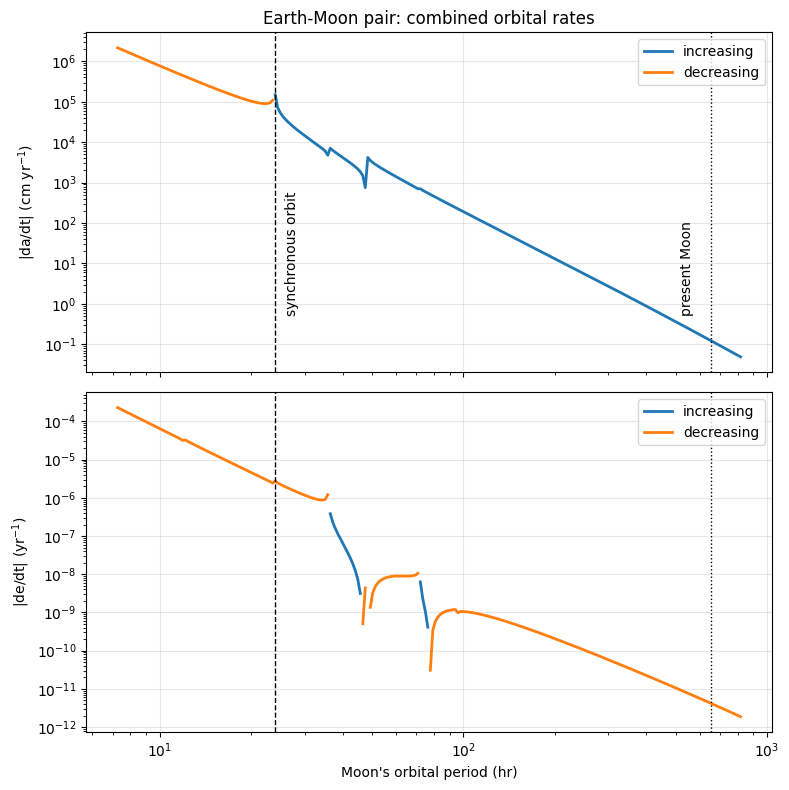

Earth's sidereal day: 23.93 hr
da/dt changes sign between 23.54 and 24.00 hr (6.57 to 6.66 Earth radii)


In [7]:
present_semi_major_axis = system.get_semi_major_axis(moon)
semi_major_axes = np.logspace(np.log10(3.0), np.log10(70.0), 250) * earth.radius   # [m]

periods_hr = np.empty_like(semi_major_axes)
da_dt = np.empty_like(semi_major_axes)
de_dt = np.empty_like(semi_major_axes)
for i, semi_major_axis in enumerate(semi_major_axes):
    system.set_semi_major_axis(moon, semi_major_axis)
    orbital_frequency = system.calc_orbital_frequency(moon)
    moon.set_spin_frequency(orbital_frequency)   # Keep the Moon synchronous
    pair_sweep = system.calc_pair_evolution(moon)
    periods_hr[i] = 2.0 * np.pi / orbital_frequency / 3600.0
    da_dt[i] = pair_sweep["da_dt"] * CM_PER_YEAR
    de_dt[i] = pair_sweep["de_dt"] * year

# Restore the present orbit
system.set_semi_major_axis(moon, present_semi_major_axis)
moon.set_spin_frequency(system.calc_orbital_frequency(moon))

sidereal_day_hr = 2.0 * np.pi / earth.spin_frequency / 3600.0
present_period_hr = 2.0 * np.pi / system.calc_orbital_frequency(moon) / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for ax, rate, label in [(axes[0], da_dt, "|da/dt| (cm yr$^{-1}$)"), (axes[1], de_dt, "|de/dt| (yr$^{-1}$)")]:
    ax.loglog(periods_hr, np.where(rate > 0.0, rate, np.nan), color="tab:blue", lw=2, label="increasing")
    ax.loglog(periods_hr, np.where(rate < 0.0, -rate, np.nan), color="tab:orange", lw=2, label="decreasing")
    ax.axvline(sidereal_day_hr, color="k", ls="--", lw=1)
    ax.axvline(present_period_hr, color="k", ls=":", lw=1)
    ax.set_ylabel(label)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
axes[0].text(sidereal_day_hr * 1.08, 0.5, "synchronous orbit", rotation=90, va="bottom")
axes[0].text(present_period_hr * 0.88, 0.5, "present Moon", rotation=90, va="bottom", ha="right")
axes[1].set_xlabel("Moon's orbital period (hr)")
axes[0].set_title("Earth-Moon pair: combined orbital rates")
fig.tight_layout()
plt.show()

print(f"Earth's sidereal day: {sidereal_day_hr:.2f} hr")
for i in np.where(np.diff(np.sign(da_dt)) != 0)[0]:
    print(f"da/dt changes sign between {periods_hr[i]:.2f} and {periods_hr[i + 1]:.2f} hr "
          f"({semi_major_axes[i] / earth.radius:.2f} to {semi_major_axes[i + 1] / earth.radius:.2f} Earth radii)")

Inside the synchronous orbit, near 6.6 Earth radii, the pair's orbit contracts, and outside it the orbit expands. The magnitude falls steeply with distance: the tidal torque scales as $a^{-6}$ before any change in the interior's frequency response.The narrow steps near orbital periods of 1.5, 2, and 3 sidereal days are where one tidal mode's forcing frequency, $(2 - 2p + q)\,n - m\,\Omega$, passes through zero. Close to zero frequency the viscous mantle dissipates strongly with a sign that follows the mode's frequency, so that mode's contribution reverses over a range of periods much narrower than the sweep's spacing.

The eccentricity rate changes sign several times between the synchronous orbit and about 3 sidereal days, as individual tidal modes change sign and the balance between the Earth's and the Moon's contributions shifts. At the present distance the Moon's own dissipation dominates and the eccentricity decays. These are instantaneous rates for the present Earth rotation. A history of the Earth-Moon system would integrate them in time, with the Earth's spin and the Moon's orbit evolving together.